# Topic detection on news headlines

Starter pipeline for **ThematicTrading** news text analysis — **first week of January 2025** (no random sampling):

1. Load headlines with **Polars** (`CaptureTime` filter, lazy scan)
2. Preprocess text with **NLTK**
3. **LDA** topic modeling (scikit-learn) — word-based themes on cleaned text
4. **Sentence embeddings** with a finance-tuned embedder on preprocessed headlines (prefix/date stripped)
5. **HDBSCAN** on a 5D UMAP projection of embeddings
6. **BERTopic** on the same embeddings (UMAP → HDBSCAN → c-TF-IDF on cleaned text)

> **What HDBSCAN clusters:** 768-d FinLang embeddings (via UMAP 5D), not raw text. UMAP 2D is for plots only.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch
import umap
from bertopic import BERTopic
from hdbscan import HDBSCAN
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE

for resource in ("punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"):
    nltk.download(resource, quiet=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- configuration ---
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "raw_news_2025.csv"
TEXT_COL = "Headline"
TOPIC_COL = "DerivedTopicsId"

# First week of 2025 (UTC, end exclusive)
DATE_START = "2025-01-01T00:00:00+00:00"
DATE_END = "2026-01-01T00:00:00+00:00"


SAMPLED_DOCS = 50_000 # -1: we use all docs, X: we sample uniformly X docs

RANDOM_SEED = 42
N_TOPICS = 8

EMBEDDING_MODEL = "FinLang/finance-embeddings-investopedia"
EMBED_BATCH_SIZE = 64

MIN_TOPIC_SIZE = 250  # ~2% of one-day corpus; raise for broader themes, lower for event-level
MIN_SAMPLES = 20
UMAP_CLUSTER_COMPONENTS = 5

TSNE_PERPLEXITY = 40  # ~30–50 works well for 10k–20k points
TSNE_MAX_ITER = 1000

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

RUN_CONFIG = pd.DataFrame(
    {
        "setting": [
            "date range",
            "sampled docs",
            "embedder",
            "LDA topics",
            "UMAP dims (clustering)",
            "HDBSCAN min_cluster_size",
            "HDBSCAN min_samples",
            "t-SNE perplexity",
        ],
        "value": [
            f"{DATE_START} → {DATE_END}",
            "all" if SAMPLED_DOCS == -1 else SAMPLED_DOCS,
            EMBEDDING_MODEL,
            N_TOPICS,
            UMAP_CLUSTER_COMPONENTS,
            MIN_TOPIC_SIZE,
            MIN_SAMPLES,
            TSNE_PERPLEXITY,
        ],
    }
)
display(RUN_CONFIG)
print(f"Device: {DEVICE}")

,setting,value
0,date range,2025-01-01T00:00:00+00:00 → 2026-01-01T00:00:0...
1,sampled docs,50000
2,embedder,FinLang/finance-embeddings-investopedia
3,LDA topics,8
4,UMAP dims (clustering),5
5,HDBSCAN min_cluster_size,250
6,HDBSCAN min_samples,20
7,t-SNE perplexity,40


Device: mps


## 1. Load data

Lazy-scan the CSV, filter by `DATE_START` → `DATE_END`, then optionally subsample:

- `SAMPLED_DOCS = -1` → use **all** headlines in the date window
- `SAMPLED_DOCS = X` → uniform random sample of **X** headlines (seed = `RANDOM_SEED`)

In [3]:
USE_COLS = [TEXT_COL, TOPIC_COL, "CaptureTime", "WireName"]

full_stats = (
    pl.scan_csv(DATA_PATH)
    .select(TEXT_COL)
    .filter(pl.col(TEXT_COL).is_not_null() & (pl.col(TEXT_COL).str.len_chars() > 0))
    .select(pl.len().alias("n_rows"), pl.col(TEXT_COL).n_unique().alias("n_unique"))
    .collect()
)
print(
    f"Duplicate headlines (full dataset): "
    f"{(1 - full_stats['n_unique'][0] / full_stats['n_rows'][0]):.1%}"
)

corpus_df = (
    pl.scan_csv(DATA_PATH)
    .select(USE_COLS)
    .with_columns(pl.col("CaptureTime").str.to_datetime(time_zone="UTC"))
    .filter(
        (pl.col("CaptureTime") >= pl.lit(DATE_START).str.to_datetime(time_zone="UTC"))
        & (pl.col("CaptureTime") < pl.lit(DATE_END).str.to_datetime(time_zone="UTC"))
        & pl.col(TEXT_COL).is_not_null()
        & (pl.col(TEXT_COL).str.len_chars() > 0)
    )
    .collect()
)

if SAMPLED_DOCS == -1:
    df = corpus_df
    sample_mode = "all docs in date range"
elif SAMPLED_DOCS > 0:
    n_sample = min(SAMPLED_DOCS, corpus_df.height)
    df = corpus_df.sample(n=n_sample, seed=RANDOM_SEED, shuffle=True)
    sample_mode = f"uniform random sample ({n_sample:,} docs, seed={RANDOM_SEED})"
else:
    raise ValueError("SAMPLED_DOCS must be -1 (all docs) or a positive integer")

daily_counts = (
    df.with_columns(pl.col("CaptureTime").dt.date().alias("date"))
    .group_by("date")
    .len()
    .sort("date")
)

summary = pd.DataFrame(
    {
        "metric": [
            "date-range corpus",
            "docs used for modeling",
            "sampling",
            "days covered",
            "avg per day (modeling set)",
            "unique wires",
            "date range",
        ],
        "value": [
            f"{corpus_df.height:,}",
            f"{df.height:,}",
            sample_mode,
            daily_counts.height,
            f"{df.height / daily_counts.height:,.0f}",
            df["WireName"].n_unique(),
            f"{DATE_START[:10]} → {DATE_END[:10]}",
        ],
    }
)

display(summary)
print("\nHeadlines per day (modeling set)")
display(daily_counts)

df.head()

Duplicate headlines (full dataset): 46.4%


,metric,value
0,date-range corpus,"17,598,191"
1,docs used for modeling,"50,000"
2,sampling,"uniform random sample (50,000 docs, seed=42)"
3,days covered,364
4,avg per day (modeling set),137
5,unique wires,172
6,date range,2025-01-01 → 2026-01-01



Headlines per day (modeling set)


date,len
date,u32
2025-01-01,31
2025-01-02,125
2025-01-03,138
2025-01-04,19
2025-01-05,31
…,…
2025-12-27,20
2025-12-28,22
2025-12-29,138


Headline,DerivedTopicsId,CaptureTime,WireName
str,str,"datetime[μs, UTC]",str
"""Simply Wall St: 3 Stocks Inclu…","""BIZNEWS;NET;FIN;BUSINESS;MISC;…",2025-10-20 17:17:33.230 UTC,"""BLG"""
"""*TOKYO CHUO AUCTION SUSPENDS T…","""BIZNEWS;HK;MSCIWORLD;CHS;ACEXC…",2025-04-23 00:36:21.579 UTC,"""BN"""
"""Simply Wall St: Assessing Viat…","""BIZNEWS;CPNYCNT1;BUSINESS;DRG;…",2025-12-20 20:18:32.910 UTC,"""BLG"""
"""Bmit Technologie: September 5,…","""BIZNEWS;CPNYCNT1;BUSINESS;MISC…",2025-09-05 10:05:45.396 UTC,"""CO5"""
"""Insider Monkey: Is Amazon (AMZ…","""BIZNEWS;CONSD;BUSINESS;CONS;MI…",2025-10-11 13:48:25.686 UTC,"""BLG"""


In [4]:
# Raw headlines below; all modeling uses preprocessed text from §2
df.select(TEXT_COL).head()

['Simply Wall St: 3 Stocks Including Extreme Networks Estimated Below Fair Value',
 '*TOKYO CHUO AUCTION SUSPENDS TRADING IN HONG KONG',
 'Simply Wall St: Assessing Viatris After Its Recent Share Price Rebound and Strategy Shift',
 'Bmit Technologie: September 5, 2025 EGM - Information on the 2025 Extraordinary General Meeting',
 'Insider Monkey: Is Amazon (AMZN) One of the Most Profitable Stocks of the Last 5 Years?']

### Colon-prefix audit

Headlines often start with `SOURCE: story`. Below we collect every prefix from the **first letter through the first `:`** in the date-filtered corpus, ranked by frequency and prefix length — use this to decide which patterns to strip in preprocessing.

In [5]:
from collections import Counter


def extract_colon_prefix(text: str) -> str | None:
    """Text from the first character up to (not including) the first colon."""
    if not text or ":" not in text:
        return None
    prefix = text.split(":", 1)[0].strip()
    if not prefix or not prefix[0].isalpha():
        return None
    return prefix


prefix_counts: Counter[str] = Counter()
for headline in corpus_df[TEXT_COL]:
    prefix = extract_colon_prefix(headline)
    if prefix:
        prefix_counts[prefix] += 1

prefix_df = (
    pd.DataFrame(
        {
            "prefix": list(prefix_counts.keys()),
            "count": list(prefix_counts.values()),
        }
    )
    .assign(length=lambda d: d["prefix"].str.len())
    .sort_values(["count", "length"], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Headlines with letter-start colon prefix: {prefix_df['count'].sum():,} / {corpus_df.height:,}")
print(f"Unique prefixes: {len(prefix_df):,}\n")

length_stats = (
    prefix_df.groupby("length", as_index=False)
    .agg(unique_prefixes=("prefix", "count"), total_headlines=("count", "sum"))
    .sort_values("length")
)
display(length_stats)

print("\nTop 40 prefixes by frequency")
display(prefix_df.head(40))

print("\nSample prefixes by length (for manual keep/strip review)")
for length in sorted(prefix_df["length"].unique())[:12]:
    sample = prefix_df.loc[prefix_df["length"] == length].head(5)
    examples = ", ".join(f"{r.prefix} ({r.count:,})" for r in sample.itertuples())
    print(f"  len {length:2d}: {examples}")

Headlines with letter-start colon prefix: 10,853,683 / 17,598,191
Unique prefixes: 418,049



,length,unique_prefixes,total_headlines
0,1,3,4
1,2,83,10211
2,3,1578,375081
3,4,2946,260863
4,5,984,92434
...,...,...,...
122,123,38,77
123,124,20,41
124,125,19,61
125,126,17,25



Top 40 prefixes by frequency


,prefix,count,length
0,BSECorpAnn,259152,10
1,NSE India,193965,9
2,Street Insider,171242,14
3,Yahoo! Finance,118780,14
4,Globe Newswire,103906,14
5,Markets Live,92546,12
6,FERC,89523,4
7,Simply Wall St,77698,14
8,Bursa Malaysia,69806,14
9,EIN Presswire,69609,13



Sample prefixes by length (for manual keep/strip review)
  len  1: K (2), t (1), Y (1)
  len  2: SN (4,436), WE (1,059), HP (948), LI (933), GQ (555)
  len  3: FEC (65,683), IPT (26,749), NZX (17,679), FDA (15,634), CNA (14,000)
  len  4: FERC (89,523), SCMP (15,636), NDTV (13,129), SFSA (10,402), CNET (7,774)
  len  5: Zawya (14,725), Metro (5,922), Sabah (4,657), Inc42 (4,000), newsX (3,760)
  len  6: PRICED (63,359), Mondaq (25,481), LAUNCH (25,391), NASDAQ (17,990), Ubs Ag (12,827)
  len  7: News 18 (31,018), US News (28,465), Vijesti (17,430), MANDATE (15,187), NewsBTC (15,179)
  len  8: RTT News (52,495), FXStreet (34,376), Newsweek (28,974), NEW DEAL (23,128), GUIDANCE (21,276)
  len  9: NSE India (193,965), Yahoo! AU (29,197), USA Today (28,843), Oslo Bors (28,194), MT5 Forex (21,593)
  len 10: BSECorpAnn (259,152), CNBC TV 18 (37,047), Yahoo News (21,757), Express UK (18,024), Bitcoinist (10,309)
  len 11: Motley Fool (39,463), The Star.my (34,302), NDTV Profit (31,301), Talk

## 2. Text preprocessing

1. **Strip colon prefixes** — remove `SOURCE:` tags (same rule as the prefix audit above)
2. **Strip dates / standalone numbers**
3. Tokenize, stopwords, lemmatize

`headlines_for_embed` (steps 1–2, natural language) feeds the embedder. `clean_headlines` (all steps) feeds LDA, BERTopic, and all downstream tables. Rows with empty text after step 3 are dropped.

In [6]:
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

DATE_PATTERNS = (
    r"\b\d{4}[/\-]\d{1,2}[/\-]\d{1,2}\b",  # 2025/04/17
    r"\b\d{1,2}[/\-]\d{1,2}[/\-]\d{2,4}\b",  # 04/17/2025
    r"\b(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)[a-z]*\.?\s+\d{1,2},?\s+\d{4}\b",
    r"\bq[1-4]\s+\d{4}\b",
)


def strip_colon_prefix(text: str) -> str:
    """Remove wire tag before first colon (matches prefix audit rule)."""
    if not text or ":" not in text:
        return text
    prefix = text.split(":", 1)[0].strip()
    if prefix and prefix[0].isalpha():
        return text.split(":", 1)[1].strip()
    return text


def strip_dates(text: str) -> str:
    for pattern in DATE_PATTERNS:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    text = re.sub(r":\s*\d+\b", ":", text)  # filing suffixes like ": 4"
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r":\s*$", "", text)
    return re.sub(r"\s+", " ", text).strip()


def normalize_headline(text: str) -> str:
    return strip_dates(strip_colon_prefix(text))


def preprocess(text: str) -> str:
    text = normalize_headline(text).lower()
    tokens = word_tokenize(text)
    tokens = [
        LEMMATIZER.lemmatize(tok)
        for tok in tokens
        if tok.isalpha() and tok not in STOPWORDS and len(tok) > 2
    ]
    return " ".join(tokens)


raw_headlines = df[TEXT_COL].to_list()
headlines_for_embed = [normalize_headline(h) for h in raw_headlines]
clean_headlines = [preprocess(h) for h in raw_headlines]

keep_idx = [i for i, text in enumerate(clean_headlines) if text.strip()]
n_dropped = len(raw_headlines) - len(keep_idx)
if n_dropped:
    print(f"Dropped {n_dropped:,} headlines with empty text after preprocessing")

df = df[keep_idx]
headlines_for_embed = [headlines_for_embed[i] for i in keep_idx]
clean_headlines = [clean_headlines[i] for i in keep_idx]

print(f"Modeling set: {len(clean_headlines):,} preprocessed headlines\n")
print("Raw vs preprocessed example:")
for raw, clean in zip(raw_headlines[:3], clean_headlines[:3]):
    print(f"  raw:            {raw}")
    print(f"  preprocessed:   {clean}\n")

clean_headlines[:5]

Raw vs stripped example:
  raw:       Simply Wall St: 3 Stocks Including Extreme Networks Estimated Below Fair Value
  stripped:  Stocks Including Extreme Networks Estimated Below Fair Value

  raw:       *TOKYO CHUO AUCTION SUSPENDS TRADING IN HONG KONG
  stripped:  *TOKYO CHUO AUCTION SUSPENDS TRADING IN HONG KONG

  raw:       Simply Wall St: Assessing Viatris After Its Recent Share Price Rebound and Strategy Shift
  stripped:  Assessing Viatris After Its Recent Share Price Rebound and Strategy Shift



['stock including extreme network estimated fair value',
 'tokyo chuo auction suspends trading hong kong',
 'assessing viatris recent share price rebound strategy shift',
 'egm information extraordinary general meeting',
 'amazon amzn one profitable stock last year']

## 3. LDA topic modeling

Bag-of-words + Latent Dirichlet Allocation. Good baseline for discovering word-based themes.

In [7]:
vectorizer = CountVectorizer(max_df=0.9, min_df=5, max_features=5_000)
doc_term_matrix = vectorizer.fit_transform(clean_headlines)

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_SEED,
    learning_method="batch",
    max_iter=20,
)
lda_doc_topics = lda.fit_transform(doc_term_matrix)
lda_labels = lda_doc_topics.argmax(axis=1)

feature_names = vectorizer.get_feature_names_out()


def top_words(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        words = [feature_names[i] for i in top_indices]
        print(f"Topic {topic_idx}: {', '.join(words)}")


top_words(lda, feature_names)

Topic 0: trump, say, tariff, new, trade, deal, china, court, talk, plan
Topic 1: market, stock, share, cut, price, fall, wrap, rise, gain, growth
Topic 2: call, earnings, say, may, rate, change, risk, air, world, new
Topic 3: report, result, financial, ltd, share, limited, sell, quarter, meeting, announcement
Topic 4: say, ceo, schedule, new, take, musk, plc, time, google, big
Topic 5: new, energy, target, buy, today, toplive, rating, price, get, project
Topic 6: net, bank, asset, million, fund, capital, value, share, investment, billion
Topic 7: est, investor, sale, revenue, profit, see, estimate, loss, beat, law


In [8]:
lda_df = pd.DataFrame({
    "headline": clean_headlines,
    "lda_topic": lda_labels,
    "lda_confidence": lda_doc_topics.max(axis=1),
})
lda_df.groupby("lda_topic").size().sort_values(ascending=False)

lda_topic
0    12819
1     6462
6     5883
3     5550
5     5466
4     5158
2     4704
7     3958
dtype: int64

## 4. Sentence embeddings

The embedder maps each **preprocessed headline** (prefix/date stripped) to a 768-dimensional vector (FinLang / BGE). Vectors are L2-normalized so cosine similarity equals Euclidean distance.

**Downstream clustering never sees the text directly** — only these vectors (optionally after UMAP dimensionality reduction).

In [9]:
embedder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)

embeddings = embedder.encode(
    headlines_for_embed,
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,  # cosine distance ≈ euclidean on unit vectors
)

print(f"Embedding matrix: {embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Embedding matrix: (50000, 768)


## 5. HDBSCAN clustering

```
preprocessed headline → FinLang embedder → 768-d vector → UMAP (5D) → HDBSCAN
                                                      ↓
                                                t-SNE (2D) for scatter plots
```

Clustering uses **UMAP 5D**; plots use **t-SNE 2D** (visualization only — labels come from each method, not from t-SNE).

`MIN_TOPIC_SIZE` / `MIN_SAMPLES` control cluster granularity. On **one day** of news, low values surface **event-level** clusters (single stories); higher values push toward **broader themes**.

Topic **-1** = outlier/noise.

In [10]:
cluster_umap = umap.UMAP(
    n_neighbors=15,
    n_components=UMAP_CLUSTER_COMPONENTS,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_SEED,
)
embedding_cluster = cluster_umap.fit_transform(embeddings)

perplexity = min(TSNE_PERPLEXITY, max(5, df.height // 100))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=RANDOM_SEED,
    max_iter=TSNE_MAX_ITER,
    learning_rate="auto",
    init="pca",
)
embedding_2d = tsne.fit_transform(embeddings)

hdb = HDBSCAN(
    min_cluster_size=MIN_TOPIC_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
)
hdb_labels = hdb.fit_predict(embedding_cluster)

cluster_df = pd.DataFrame({
    "headline": clean_headlines,
    "hdbscan_cluster": hdb_labels,
    "lda_topic": lda_labels,
    "tsne_x": embedding_2d[:, 0],
    "tsne_y": embedding_2d[:, 1],
})

n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
print(f"HDBSCAN input space:  UMAP {UMAP_CLUSTER_COMPONENTS}D (from 768-d embeddings)")
print(f"t-SNE viz:            2D (perplexity={perplexity})")
print(f"HDBSCAN clusters:     {n_hdb} (excluding outliers)")
print(f"Outlier headlines:    {(hdb_labels == -1).sum()} ({(hdb_labels == -1).mean():.1%})")
cluster_df.head()

HDBSCAN input space:  UMAP 5D (from 768-d embeddings)
t-SNE viz:            2D (perplexity=40)
HDBSCAN clusters:     37 (excluding outliers)
Outlier headlines:    23744 (47.5%)


,headline,headline_raw,hdbscan_cluster,lda_topic,tsne_x,tsne_y
0,Stocks Including Extreme Networks Estimated Be...,Simply Wall St: 3 Stocks Including Extreme Net...,-1,4,11.924490,42.880386
1,*TOKYO CHUO AUCTION SUSPENDS TRADING IN HONG KONG,*TOKYO CHUO AUCTION SUSPENDS TRADING IN HONG KONG,-1,0,-1.847871,-37.690815
2,Assessing Viatris After Its Recent Share Price...,Simply Wall St: Assessing Viatris After Its Re...,-1,1,-40.490562,17.590179
3,EGM - Information on the Extraordinary General...,"Bmit Technologie: September 5, 2025 EGM - Info...",11,3,-12.615159,-57.618225
4,Is Amazon (AMZN) One of the Most Profitable St...,Insider Monkey: Is Amazon (AMZN) One of the Mo...,25,1,4.217874,43.147636


In [11]:
# Unified scatter plots live in §7 (after BERTopic assigns bertopic_topic)
print(f"HDBSCAN: {n_hdb} clusters, {(hdb_labels == -1).sum():,} outliers")

HDBSCAN: 37 clusters, 23,744 outliers


## 6. BERTopic

Same clustering params as HDBSCAN, plus **c-TF-IDF keywords** on cleaned text. The **3-method scatter plot** (LDA / HDBSCAN / BERTopic) is in the next cell.

In [12]:
bertopic_vectorizer = CountVectorizer(
    stop_words="english",
    token_pattern=r"(?u)\b[a-zA-Z]{3,}\b",
    min_df=2,
    max_df=0.9,
)

bertopic_umap = umap.UMAP(
    n_neighbors=15,
    n_components=UMAP_CLUSTER_COMPONENTS,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_SEED,
)
bertopic_hdbscan = HDBSCAN(
    min_cluster_size=MIN_TOPIC_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=embedder,
    umap_model=bertopic_umap,
    hdbscan_model=bertopic_hdbscan,
    vectorizer_model=bertopic_vectorizer,
    verbose=True,
)

bertopic_topics, _ = topic_model.fit_transform(clean_headlines, embeddings)
cluster_df["bertopic_topic"] = bertopic_topics

n_bertopic = len(set(bertopic_topics)) - (1 if -1 in bertopic_topics else 0)
print(f"BERTopic topics (excl. outliers): {n_bertopic}")
print(f"Outlier headlines: {(np.array(bertopic_topics) == -1).sum()} ({(np.array(bertopic_topics) == -1).mean():.1%})")

topic_info = topic_model.get_topic_info()
topic_info[topic_info.Topic != -1].head(15)

2026-05-25 11:06:08,887 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-25 11:07:18,533 - BERTopic - Dimensionality - Completed ✓
2026-05-25 11:07:18,537 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-25 11:07:20,224 - BERTopic - Cluster - Completed ✓
2026-05-25 11:07:20,236 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-25 11:07:20,447 - BERTopic - Representation - Completed ✓


BERTopic topics (excl. outliers): 37
Outlier headlines: 22581 (45.2%)


,Topic,Count,Name,Representation,Representative_Docs
1,0,2818,0_law_investor_trump_class,"[law, investor, trump, class, lawsuit, musk, a...",[jspr investor opportunity lead jasper therape...
2,1,1957,1____,"[, , , , , , , , , ]","[, , ]"
3,2,1763,2_est_rev_income_net,"[est, rev, income, net, adj, area, eps, rupee,...","[ocular therapeutix rev est, s adj ebitda est ..."
4,3,1376,3_buy_sell_acquire_stake,"[buy, sell, acquire, stake, acquisition, acqui...",[clearway energy sign binding agreement acquir...
5,4,1244,4_apple_nvidia_openai_google,"[apple, nvidia, openai, google, chip, iphone, ...",[microsoft unveils quantum computing chip futu...
6,5,1083,5_rating_raised_target_buy,"[rating, raised, target, buy, adjusts, rated, ...",[barclays adjusts price target maintains overw...
7,6,975,6_conference_presentation_meeting_annual,"[conference, presentation, meeting, annual, re...","[notice annual general meeting, notice annual ..."
8,7,948,7_bitcoin_crypto_xrp_ethereum,"[bitcoin, crypto, xrp, ethereum, btc, price, s...",[best crypto invest october big investor look ...
9,8,908,8_appoints_ceo_chief_board,"[appoints, ceo, chief, board, director, office...","[gannett appoints trisha gosser cfo, appoints ..."
10,9,894,9_netflix_warner_award_star,"[netflix, warner, award, star, movie, film, pa...",[netflix billion loan warner among biggest eve...


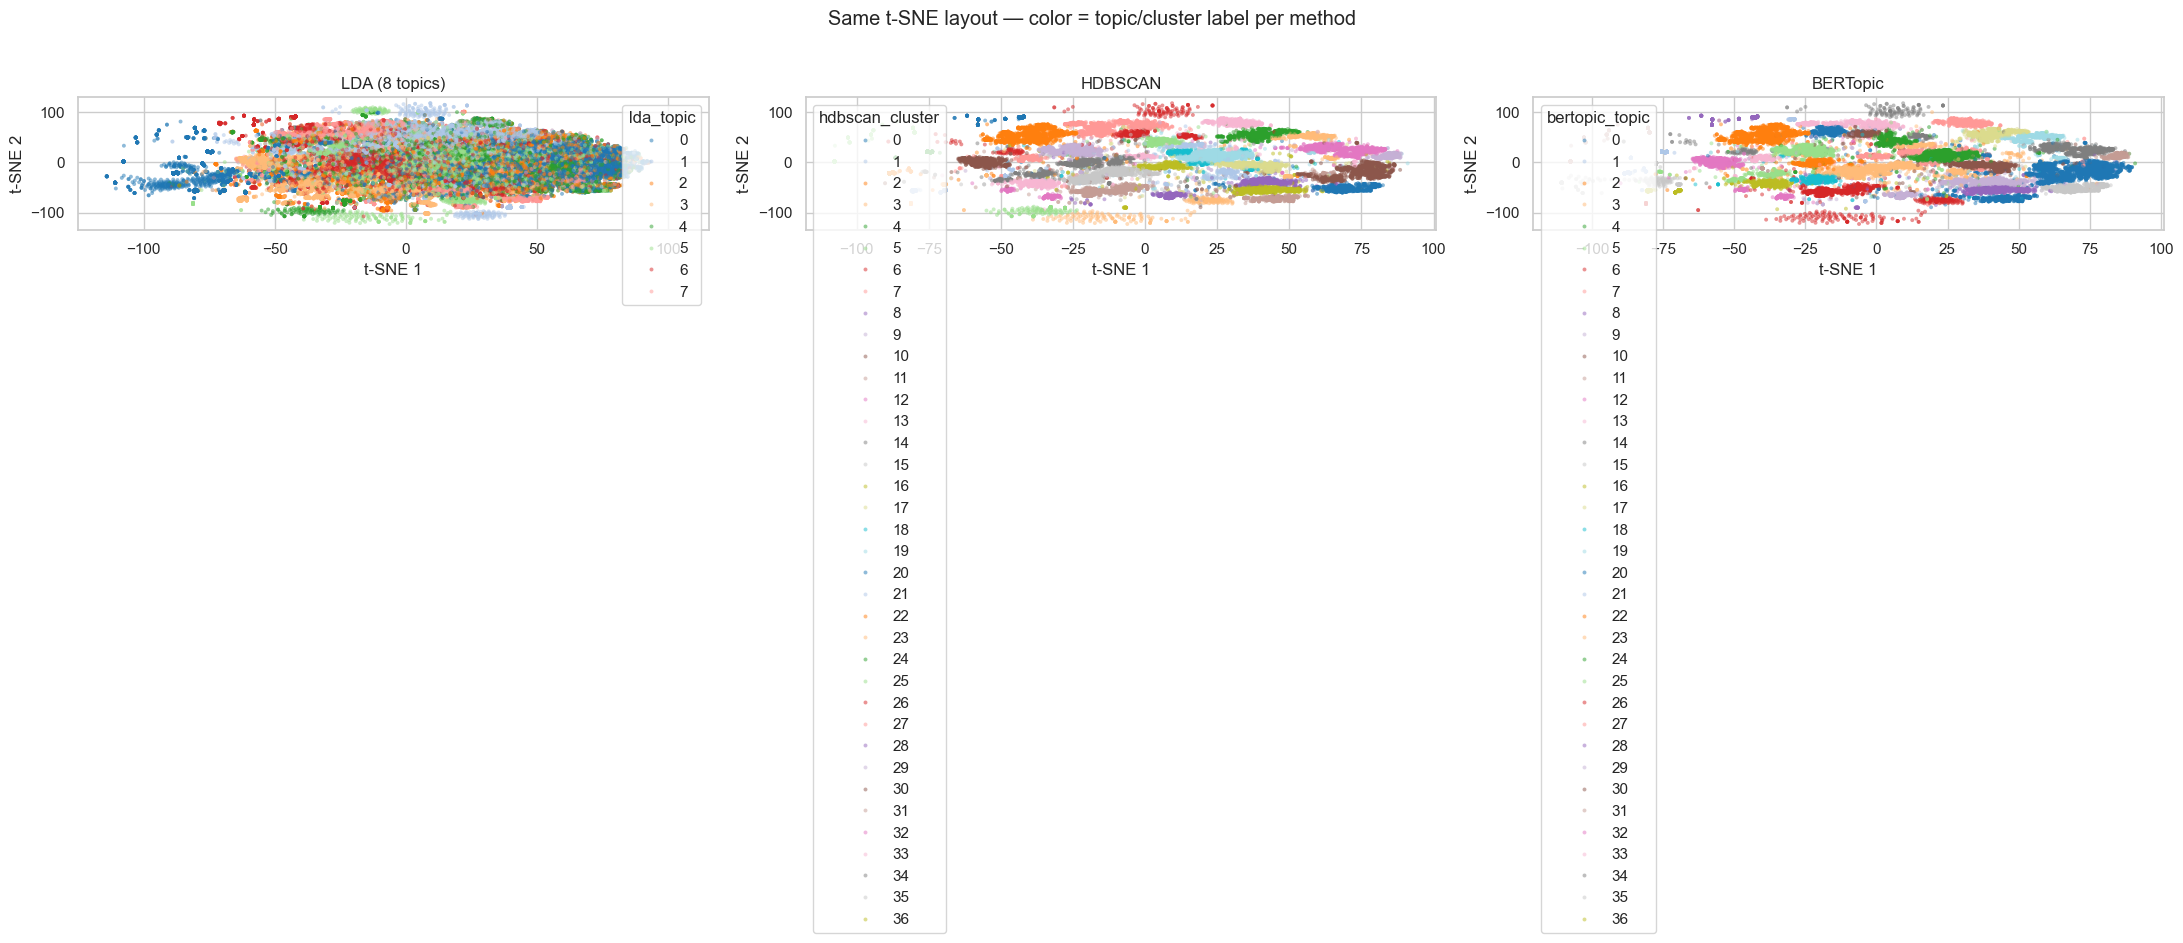

In [13]:
def method_scatter(data: pd.DataFrame, col: str, title: str, ax: plt.Axes) -> None:
    if col in ("hdbscan_cluster", "bertopic_topic"):
        data = data[data[col] != -1]
    sns.scatterplot(
        data=data,
        x="tsne_x",
        y="tsne_y",
        hue=col,
        palette="tab20",
        s=8,
        alpha=0.5,
        linewidth=0,
        legend="brief",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

method_scatter(cluster_df, "lda_topic", f"LDA ({N_TOPICS} topics)", axes[0])
method_scatter(cluster_df, "hdbscan_cluster", "HDBSCAN", axes[1])
method_scatter(cluster_df, "bertopic_topic", "BERTopic", axes[2])

plt.suptitle("Same t-SNE layout — color = topic/cluster label per method", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
def print_bertopic_keywords(topic_model: BERTopic, n_words: int = 10) -> None:
    for topic_id in sorted(t for t in topic_model.topics_ if t != -1):
        words = topic_model.get_topic(topic_id)
        if not words:
            continue
        label = ", ".join(word for word, _ in words[:n_words])
        print(f"Topic {topic_id}: {label}")


print_bertopic_keywords(topic_model)

Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, investor, trump, class, lawsuit, musk, action, court, firm, contact
Topic 0: law, in

## 7. Compare LDA, HDBSCAN, and BERTopic

Summary stats and cross-tabs. **3-panel scatter plot** is in §6 (right after BERTopic fit).

In [15]:
def count_groups(labels, exclude_outliers: bool = True) -> int:
    unique = set(labels)
    if exclude_outliers:
        unique.discard(-1)
    return len(unique)


comparison_summary = pd.DataFrame(
    {
        "method": ["LDA", "HDBSCAN", "BERTopic"],
        "n_groups": [
            count_groups(lda_labels, exclude_outliers=False),
            count_groups(hdb_labels),
            count_groups(bertopic_topics),
        ],
        "outliers": [
            0,
            int((hdb_labels == -1).sum()),
            int((np.array(bertopic_topics) == -1).sum()),
        ],
    }
)
display(comparison_summary)

assigned = cluster_df[(cluster_df["hdbscan_cluster"] != -1) & (cluster_df["bertopic_topic"] != -1)]
print(f"\nHeadlines assigned by both HDBSCAN and BERTopic: {len(assigned):,} / {len(cluster_df):,}")

print("\nHDBSCAN vs BERTopic (excluding -1 on both axes):")
hdb_assigned = cluster_df[cluster_df["hdbscan_cluster"] != -1]
bt_assigned = cluster_df[cluster_df["bertopic_topic"] != -1]
cross = pd.crosstab(hdb_assigned["hdbscan_cluster"], bt_assigned["bertopic_topic"])
display(cross.iloc[:12, :12])

,method,n_groups,outliers
0,LDA,8,0
1,HDBSCAN,37,23744
2,BERTopic,37,22581



Headlines assigned by both HDBSCAN and BERTopic: 24,788 / 50,000

HDBSCAN vs BERTopic (excluding -1 on both axes):


bertopic_topic,0,1,2,3,4,5,6,7,8,9,10,11
hdbscan_cluster,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0
4,0,1957,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,830
6,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0


## 8. Inspect clusters

Sample headlines per cluster to interpret discovered themes.

In [19]:
from collections import Counter


def lda_topic_names(model, feature_names, n_words: int = 5) -> dict[int, str]:
    return {
        topic_id: ", ".join(feature_names[i] for i in topic.argsort()[-n_words:][::-1])
        for topic_id, topic in enumerate(model.components_)
    }


def bertopic_topic_names(topic_model: BERTopic, n_words: int = 5) -> dict[int, str]:
    return {
        topic_id: ", ".join(word for word, _ in topic_model.get_topic(topic_id)[:n_words])
        for topic_id in set(topic_model.topics_)
        if topic_id != -1 and topic_model.get_topic(topic_id)
    }


def cluster_keyword_names(
    df: pd.DataFrame,
    cluster_col: str,
    text_col: str = "headline",
    n_words: int = 5,
) -> dict[int, str]:
    """Top terms per cluster from already-preprocessed token strings."""
    names: dict[int, str] = {}
    for cluster_id in sorted(df.loc[df[cluster_col] != -1, cluster_col].unique()):
        texts = df.loc[df[cluster_col] == cluster_id, text_col]
        texts = texts[texts.str.strip().astype(bool)]
        if texts.empty:
            continue
        counts: Counter[str] = Counter(
            word for text in texts for word in text.split() if word
        )
        if not counts:
            continue
        names[cluster_id] = ", ".join(w for w, _ in counts.most_common(n_words))
    return names


def sample_cluster_headlines(
    df: pd.DataFrame,
    cluster_col: str,
    names: dict[int, str] | None = None,
    n: int = 5,
) -> None:
    valid = df[df[cluster_col] != -1]
    for cluster_id in sorted(valid[cluster_col].unique()):
        subset = valid.loc[valid[cluster_col] == cluster_id, "headline"]
        keywords = (names or {}).get(cluster_id, "")
        title = f"cluster {cluster_id}" + (f" — {keywords}" if keywords else "")
        print(f"\n=== {title} ({len(subset)} docs) ===")
        for headline in subset.sample(min(n, len(subset)), random_state=RANDOM_SEED):
            print(f"  • {headline}")


lda_names = lda_topic_names(lda, feature_names)
hdb_names = cluster_keyword_names(cluster_df, "hdbscan_cluster")
bt_names = bertopic_topic_names(topic_model)

print("LDA")
sample_cluster_headlines(cluster_df, "lda_topic", names=lda_names)

print("\nHDBSCAN")
sample_cluster_headlines(cluster_df, "hdbscan_cluster", names=hdb_names)

print("\nBERTopic")
sample_cluster_headlines(cluster_df, "bertopic_topic", names=bt_names)

ValueError: After pruning, no terms remain. Try a lower min_df or a higher max_df.

In [18]:
cluster_df[["headline", "hdbscan_cluster", "bertopic_topic", "lda_topic"]].head()

Headline,DerivedTopicsId,CaptureTime,WireName
str,str,"datetime[μs, UTC]",str
"""Simply Wall St: 3 Stocks Inclu…","""BIZNEWS;NET;FIN;BUSINESS;MISC;…",2025-10-20 17:17:33.230 UTC,"""BLG"""
"""*TOKYO CHUO AUCTION SUSPENDS T…","""BIZNEWS;HK;MSCIWORLD;CHS;ACEXC…",2025-04-23 00:36:21.579 UTC,"""BN"""
"""Simply Wall St: Assessing Viat…","""BIZNEWS;CPNYCNT1;BUSINESS;DRG;…",2025-12-20 20:18:32.910 UTC,"""BLG"""
"""Bmit Technologie: September 5,…","""BIZNEWS;CPNYCNT1;BUSINESS;MISC…",2025-09-05 10:05:45.396 UTC,"""CO5"""
"""Insider Monkey: Is Amazon (AMZ…","""BIZNEWS;CONSD;BUSINESS;CONS;MI…",2025-10-11 13:48:25.686 UTC,"""BLG"""
…,…,…,…
"""*RUSSIA'S MOSCOW REFINERY OPER…","""BIZNEWS;MSCIWORLD;RUSSIA;ACEXC…",2025-03-16 22:15:08.683 UTC,"""BN"""
"""West Australian: Ora Banda Min…","""METALKEY;BIZNEWS;CPNYCNT1;BUSI…",2025-10-08 18:00:37.252 UTC,"""NS6"""
"""Metacon publishes interim repo…","""BIZNEWS;ERN;BUSINESS;UTI;ACC;C…",2025-05-15 06:23:17.001 UTC,"""PRN"""


## 9. Export interactive HTML

Interactive **BERTopic** t-SNE plot (hover → keywords + headline preview) and a **top headlines** section per cluster.

In [ ]:
import html as html_lib

import plotly.express as px

TOP_HEADLINES_PER_CLUSTER = 10
OUTPUT_HTML = PROJECT_ROOT / "notebooks" / "output" / "bertopic_clusters.html"
OUTPUT_HTML.parent.mkdir(parents=True, exist_ok=True)

topic_names = {
    topic_id: ", ".join(word for word, _ in topic_model.get_topic(topic_id)[:8])
    for topic_id in set(bertopic_topics)
    if topic_id != -1 and topic_model.get_topic(topic_id)
}
plot_data = cluster_df[cluster_df["bertopic_topic"] != -1].copy()
plot_data["keywords"] = plot_data["bertopic_topic"].map(topic_names)
plot_data["topic_label"] = plot_data["bertopic_topic"].astype(str)

fig = px.scatter(
    plot_data,
    x="tsne_x",
    y="tsne_y",
    color="topic_label",
    custom_data=["bertopic_topic", "keywords", "headline"],
    title="BERTopic clusters (t-SNE)",
    labels={"tsne_x": "t-SNE 1", "tsne_y": "t-SNE 2", "topic_label": "topic"},
    opacity=0.55,
)
fig.update_traces(
    marker={"size": 5},
    hovertemplate=(
        "<b>Topic %{customdata[0]}</b><br>"
        "%{customdata[1]}<br>"
        "<i>%{customdata[2]}</i><extra></extra>"
    ),
)
fig.update_layout(legend={"title": "bertopic_topic"}, width=1100, height=650)

cluster_sections: list[str] = []
for topic_id in sorted(plot_data["bertopic_topic"].unique()):
    keywords = topic_names.get(topic_id, "")
    subset = plot_data.loc[plot_data["bertopic_topic"] == topic_id, "headline"]
    top_headlines = subset.sample(
        min(TOP_HEADLINES_PER_CLUSTER, len(subset)),
        random_state=RANDOM_SEED,
    ).tolist()
    items = "\n".join(f"<li>{html_lib.escape(headline)}</li>" for headline in top_headlines)
    cluster_sections.append(
        f"""
        <section class="cluster">
          <h3>Topic {topic_id} — {keywords} <span class="count">({len(subset):,} docs)</span></h3>
          <ul>{items}</ul>
        </section>
        """
    )

n_outliers = (cluster_df["bertopic_topic"] == -1).sum()
plot_html = fig.to_html(full_html=False, include_plotlyjs="cdn")

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="utf-8"/>
  <title>BERTopic clusters</title>
  <style>
    body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", sans-serif; margin: 24px; color: #1a1a1a; }}
    h1 {{ margin-bottom: 0.2rem; }}
    .meta {{ color: #555; margin-bottom: 1.5rem; }}
    .cluster {{ margin-bottom: 1.75rem; padding-bottom: 1rem; border-bottom: 1px solid #e5e5e5; }}
    .cluster h3 {{ margin-bottom: 0.5rem; }}
    .count {{ color: #666; font-weight: normal; font-size: 0.95rem; }}
    ul {{ margin-top: 0.25rem; }}
    li {{ margin-bottom: 0.35rem; }}
  </style>
</head>
<body>
  <h1>BERTopic cluster explorer</h1>
  <p class="meta">
    {len(plot_data):,} assigned headlines · {len(topic_names)} topics · {n_outliers:,} outliers excluded<br/>
    Date range: {DATE_START[:10]} → {DATE_END[:10]} · Hover points for keywords
  </p>
  {plot_html}
  <h2>Top headlines by cluster</h2>
  {''.join(cluster_sections)}
</body>
</html>
"""

OUTPUT_HTML.write_text(html, encoding="utf-8")
print(f"Saved: {OUTPUT_HTML}")

## Next steps

- Batch-embed weeks to parquet if running multiple date windows
- Tune `MIN_TOPIC_SIZE` if outlier rate is too high on full-week runs
- Persist labeled parquet: `headline`, `CaptureTime`, `hdbscan_cluster`, `bertopic_topic`, `lda_topic`
- Add FinBERT sentiment as a separate feature (`ProsusAI/finbert`)